# Analysis of USATT Elo System

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
point_spread_bounds = [(0,12), (13,37), (38,62), (63,87), (88,112), (113,137), (138,162), (163,187), (188,212), (213,237), (238,np.inf)]
point_spread_index = pd.IntervalIndex.from_tuples(point_spread_bounds, closed="both")

expected_result_rating_change = [8, 7, 6, 5, 4, 3, 2, 2, 1, 1, 0]
upset_result_rating_change = [8, 10, 13, 16, 20, 25, 30, 35, 40, 45, 50]

rating_changes = pd.DataFrame(index=point_spread_index, data={"expected": expected_result_rating_change, "upset": upset_result_rating_change})
rating_changes

,expected,upset
"[0.0, 12.0]",8,8
"[13.0, 37.0]",7,10
"[38.0, 62.0]",6,13
"[63.0, 87.0]",5,16
"[88.0, 112.0]",4,20
"[113.0, 137.0]",3,25
"[138.0, 162.0]",2,30
"[163.0, 187.0]",2,35
"[188.0, 212.0]",1,40
"[213.0, 237.0]",1,45


In [3]:
rating_changes['expected result per upset'] = rating_changes['upset'] / rating_changes['expected']
rating_changes['upset probability'] = 1 / (rating_changes['expected result per upset'] + 1)
rating_changes['expected probability'] = 1 - rating_changes['upset probability']

rating_changes['rating spread'] = rating_changes.index.left
rating_changes['lower rating spread'] = -rating_changes.index.left

lowerbound = -rating_changes['rating spread'].iloc[-1]
upperbound = rating_changes['rating spread'].iloc[-1]

x_axis = np.arange(lowerbound, upperbound)

x_bounds = rating_changes['lower rating spread'][::-1].to_list() + rating_changes['rating spread'].to_list()

rating_changes["probability derivative"] = rating_changes["expected probability"] - np.roll(rating_changes["expected probability"], 1)

rating_changes

,expected,upset,expected result per upset,upset probability,expected probability,rating spread,lower rating spread,probability derivative
"[0.0, 12.0]",8,8,1.000000,0.500000,0.500000,0.0,-0.0,-0.500000
"[13.0, 37.0]",7,10,1.428571,0.411765,0.588235,13.0,-13.0,0.088235
"[38.0, 62.0]",6,13,2.166667,0.315789,0.684211,38.0,-38.0,0.095975
"[63.0, 87.0]",5,16,3.200000,0.238095,0.761905,63.0,-63.0,0.077694
"[88.0, 112.0]",4,20,5.000000,0.166667,0.833333,88.0,-88.0,0.071429
"[113.0, 137.0]",3,25,8.333333,0.107143,0.892857,113.0,-113.0,0.059524
"[138.0, 162.0]",2,30,15.000000,0.062500,0.937500,138.0,-138.0,0.044643
"[163.0, 187.0]",2,35,17.500000,0.054054,0.945946,163.0,-163.0,0.008446
"[188.0, 212.0]",1,40,40.000000,0.024390,0.975610,188.0,-188.0,0.029664
"[213.0, 237.0]",1,45,45.000000,0.021739,0.978261,213.0,-213.0,0.002651


In [4]:
from scipy.optimize import curve_fit

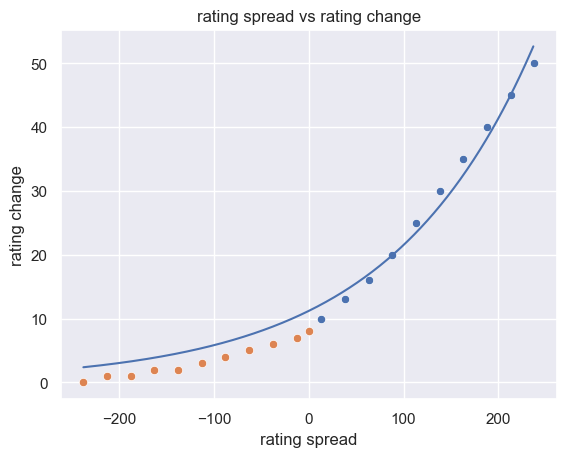

In [5]:
sns.scatterplot(data=rating_changes, x='rating spread', y='upset')
sns.scatterplot(data=rating_changes, x=-rating_changes['rating spread'], y='expected')

y_axis = np.append(rating_changes['expected'][::-1].to_numpy(), rating_changes['upset'].to_numpy())

def exp(x, a, b):
    return a * 10 ** (b * x)

parameters = curve_fit(exp, xdata=rating_changes['rating spread'], ydata=rating_changes['upset'], p0=[8, 0.01])[0]

sns.lineplot(x=x_axis, y=exp(x_axis, *parameters))
plt.xlabel("rating spread")
plt.ylabel("rating change")
plt.title(f"rating spread vs rating change")
plt.show()

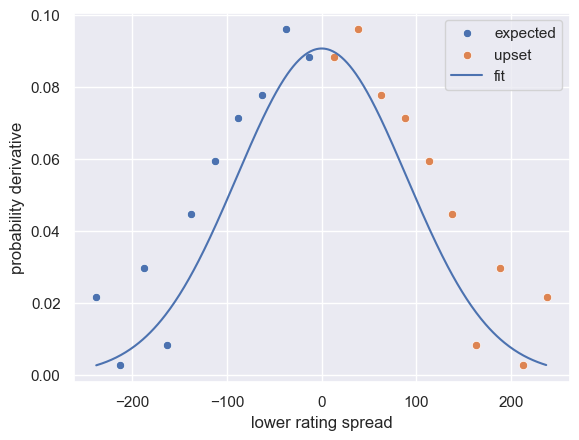

In [6]:
sns.scatterplot(x=rating_changes['lower rating spread'].iloc[1:], y=rating_changes["probability derivative"].iloc[1:], label='expected')
sns.scatterplot(x=rating_changes['rating spread'].iloc[1:], y=rating_changes["probability derivative"].iloc[1:], label='upset')

ydata = rating_changes['probability derivative'].iloc[:0:-1].to_list() + rating_changes['probability derivative'].iloc[1:].to_list()

def normal_pdf(x, scale, mu, sigma):
    return scale / np.sqrt(2 * np.pi * sigma) * np.e ** (-(x - mu) ** 2 / (2 * sigma))

derivative_params = curve_fit(normal_pdf, x_bounds[1:-1], ydata, p0=[0.3, 0, 50])[0]

sns.lineplot(x=x_axis, y=normal_pdf(x_axis, *derivative_params), label="fit")
plt.show()

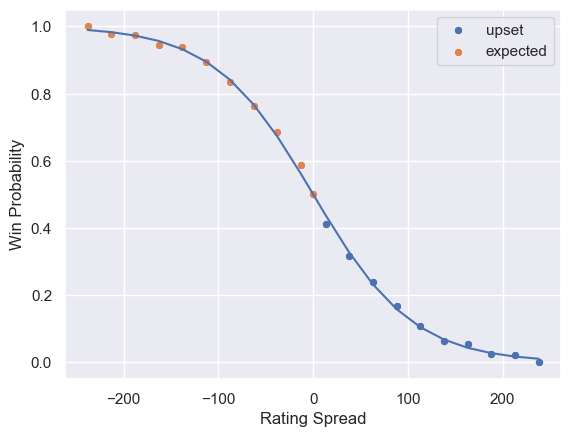

In [7]:
def sigmoid(x, k):
    return 1 / (1 + 10 ** (x / k))

ydata = rating_changes['expected probability'][::-1].to_list() + rating_changes['upset probability'].to_list()

sigmoid_params = curve_fit(sigmoid, x_bounds, ydata, p0=400)[0]

sns.scatterplot(data=rating_changes, x="rating spread", y="upset probability", label='upset')
sns.scatterplot(data=rating_changes, x="lower rating spread", y="expected probability", label='expected')
sns.lineplot(x=x_bounds, y=sigmoid(x_bounds, *sigmoid_params))
plt.xlabel('Rating Spread')
plt.ylabel('Win Probability')
plt.show()

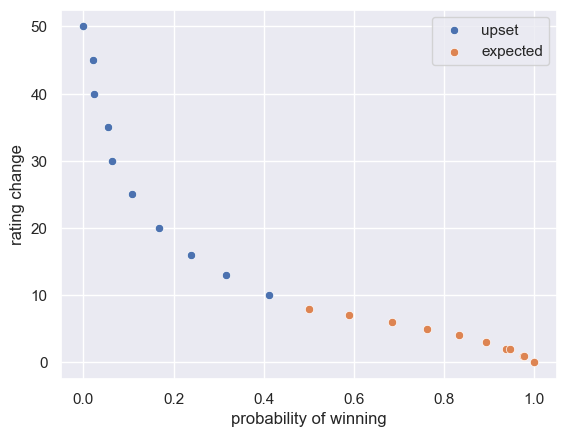

In [8]:
sns.scatterplot(data=rating_changes, x="upset probability", y="upset", label='upset')
sns.scatterplot(data=rating_changes, x="expected probability", y="expected", label='expected')
plt.xlabel('probability of winning')
plt.ylabel('rating change')
plt.show()

C:\Users\hsu_s\AppData\Local\Temp\ipykernel_26276\2491412332.py:2: RuntimeWarning: invalid value encountered in log10
  return -1/k * np.log10((1 - x ** v) / (Q * x ** v)) + m


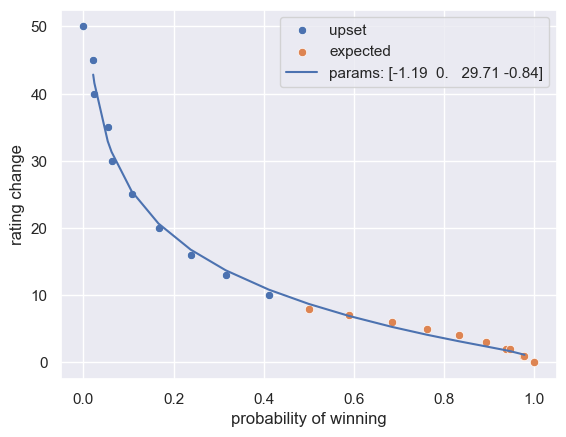

In [9]:
def inv_sigmoid(x, k, Q, v, m):
    return -1/k * np.log10((1 - x ** v) / (Q * x ** v)) + m

xdata = (rating_changes['upset probability'][::-1].to_list() + rating_changes['expected probability'].to_list())[1:-1]
ydata = (rating_changes['upset'][::-1].to_list() + rating_changes['expected'].to_list())[1:-1]

xdata = np.array(xdata)
ydata = np.array(ydata)

initial_values = [-1, 1, 2, 0]

inv_sigmoid_params = curve_fit(inv_sigmoid, xdata, ydata, p0=initial_values)[0]

sns.scatterplot(data=rating_changes, x="upset probability", y="upset", label='upset')
sns.scatterplot(data=rating_changes, x="expected probability", y="expected", label='expected')
sns.lineplot(x=xdata, y=inv_sigmoid(xdata, *inv_sigmoid_params), label=f"params: {np.round(inv_sigmoid_params, 2)}")
plt.xlabel('probability of winning')
plt.ylabel('rating change')
plt.show()